In [10]:
import cv2
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras import Sequential
from keras.layers import *
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras.applications import *
from tensorflow.keras.callbacks import EarlyStopping
import warnings 

# warnings.filterwarnings("ignore")

In [6]:
x = os.listdir('C:/Users/Mark/Desktop/PadChest/0')

# for f in x:
#     print(f)

In [43]:
# Data_Dir
# C:/Users/Mark/Desktop/PadChest

data_dir = 'C:/Users/Mark/Desktop/PadChest/0'  
csv_file = 'C:/Users/Mark/Desktop/PadChest/padchest_labels.csv' 

IMAGE_SIZE = (256,256)
BATCH_SIZE = 32
EPOCHS = 10

# checks if image file exists
def file_exists(image_id):
    image_path = os.path.join(data_dir, image_id)
    return os.path.exists(image_path)

# Safely parse the 'Labels' column and handle errors
def parse_labels(label_entry):
    if isinstance(label_entry, str):  # Ensure the entry is a string
        try:
            return eval(label_entry)  # Evaluate the string
        except Exception as e:
            print(f"Error evaluating label: {label_entry}. Error: {e}")
            return []  # Return an empty list for problematic entries
    return []  # Return an empty list if the entry is not a string

# metadata csv file
df = pd.read_csv(csv_file)

# filter out rows where the image file doesn't exist
df['File_Exists'] = df['ImageID'].apply(file_exists)
df = df[df['File_Exists']].drop(columns=['File_Exists'])

# Apply the safe parsing function
df['Parsed_Labels'] = df['Labels'].apply(parse_labels)

# Get all unique labels from the parsed labels
all_classes = set(label for label_list in df['Parsed_Labels'] for label in label_list)

# Map classes to indices
class_to_index = {class_name: idx for idx, class_name in enumerate(all_classes)}

# One-hot encode the parsed labels
def encode_labels(label_list):
    binary_vector = [0] * len(class_to_index)
    for label in label_list:
        if label in class_to_index:
            binary_vector[class_to_index[label]] = 1
    return binary_vector

# Apply encoding to the Parsed_Labels column
df['Encoded_Labels'] = df['Parsed_Labels'].apply(encode_labels)


# split the data into training, validation, and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=999)
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=999)

In [44]:
# Helper function to preprocess images
def preprocess_image(path, label):
    # Load the image from the given path
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)  # Decode as RGB
    image = tf.image.resize(image, IMAGE_SIZE)  # Resize the image
    image = image / 255.0  # Normalize pixel values
    
    # Ensure the label is converted to a float32 tensor
    label = tf.cast(label, tf.float32)  # Convert label to float32
    
    return image, label

# Helper function to create datasets
def create_dataset(dataframe):
    # Map image paths to full paths
    dataframe['ImageID'] = dataframe['ImageID'].apply(lambda x: os.path.join(data_dir, x))
    # Create a TensorFlow dataset
    paths = dataframe['ImageID'].values
    labels = list(dataframe['Encoded_Labels'].values)
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(preprocess_image).batch(BATCH_SIZE)
    return dataset

In [45]:
# Create datasets
train_ds = create_dataset(train_df)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

In [49]:
# Define the model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(class_to_index), activation='sigmoid')  # Sigmoid for multi-label classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Multi-label classification loss
    metrics=['accuracy']
)


C:\Users\Mark\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
# Train the model
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Save the model
model.save('multi_label_xray_model.h5')

# To visualize class indices
print("Class-to-Index Mapping:", class_to_index)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 65s 919ms/step - accuracy: 0.0841 - loss: 0.3733 - val_accuracy: 0.3112 - val_loss: 0.0597
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 61s 883ms/step - accuracy: 0.2862 - loss: 0.0577 - val_accuracy: 0.3112 - val_loss: 0.0583
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 61s 882ms/step - accuracy: 0.2988 - loss: 0.0549 - val_accuracy: 0.2946 - val_loss: 0.0585
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 61s 882ms/step - accuracy: 0.3097 - loss: 0.0522 - val_accuracy: 0.3029 - val_loss: 0.0612
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 61s 886ms/step - accuracy: 0.3483 - loss: 0.0481 - val_accuracy: 0.2988 - val_loss: 0.0635
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 61s 893ms/step - accuracy: 0.3961 - loss: 0.0426 - val_accuracy: 0.2697 - val_loss: 0.0668
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 62s 910ms/step - accuracy: 0.4554 - loss: 0.0365 - val_accuracy: 0.2324 - val_loss: 0.0707
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 61s 884ms/step - accuracy: 0.4904 - loss: 0.0310 - val_accu

Test Loss: 0.0910763293504715
Test Accuracy: 0.2745424211025238
Class-to-Index Mapping: {'pseudonodule': 0, 'mammary prosthesis': 1, 'adenopathy': 2, 'lung vascular paucity': 3, 'hydropneumothorax': 4, 'normal': 5, 'bronchiectasis': 6, 'miliary opacities': 7, 'minor fissure thickening': 8, 'mastectomy': 9, 'cardiomegaly': 10, 'pulmonary hypertension': 11, 'total atelectasis': 12, 'callus rib fracture': 13, 'calcified granuloma': 14, 'subacromial space narrowing': 15, 'axial hyperostosis': 16, 'pleural thickening': 17, 'heart insufficiency': 18, 'apical pleural thickening': 19, 'central venous catheter via jugular vein': 20, 'increased density': 21, 'respiratory distress': 22, 'emphysema': 23, 'sclerotic bone lesion': 24, 'central venous catheter via subclavian vein': 25, 'mediastinic lipomatosis': 26, 'mediastinal enlargement': 27, 'azygoesophageal recess shift': 28, 'cervical rib': 29, 'osteosynthesis material': 30, 'pleural effusion': 31, 'sternotomy': 32, 'nipple shadow': 33, 'surge

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


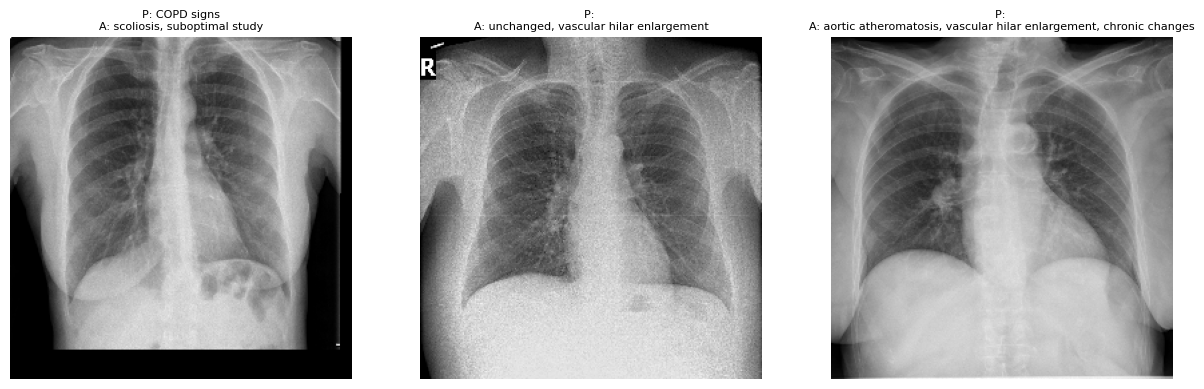

In [55]:
import matplotlib.pyplot as plt

# Function to visualize predictions vs actual labels
def visualize_predictions(model, dataset, class_names, num_images=3):
    # Get a batch of data
    for images, labels in dataset.take(1):
        # Predict on the images
        predictions = model.predict(images)
        predicted_classes = tf.argmax(predictions, axis=1)
        actual_classes = tf.argmax(labels, axis=1)

        # Plot the images with predictions
        plt.figure(figsize=(15, 15))
        for i in range(num_images):
            plt.subplot(1, num_images, i + 1)
            plt.imshow(images[i].numpy())
            plt.axis('off')
            predicted_label = ", ".join([class_names[idx] for idx, pred in enumerate(predictions[i]) if pred > 0.5])
            actual_label = ", ".join([class_names[idx] for idx in range(len(class_names)) if labels[i][idx]])
            plt.title(f"P: {predicted_label}\nA: {actual_label}", fontsize=8)
        plt.show()
        break

visualize_predictions(model, test_ds, list(class_to_index.keys()))
